In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings

warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


EDA

In [6]:
df.shape

(1338, 7)

In [7]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [11]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

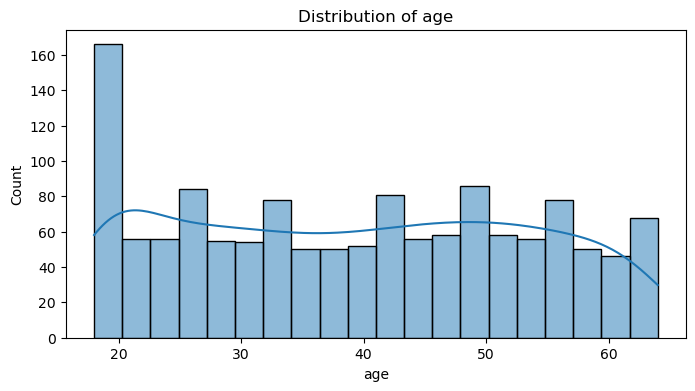

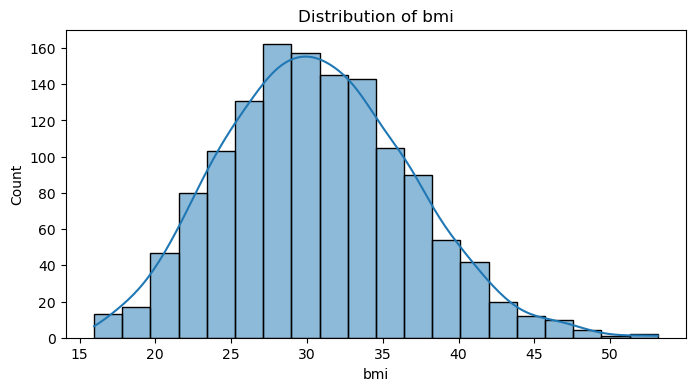

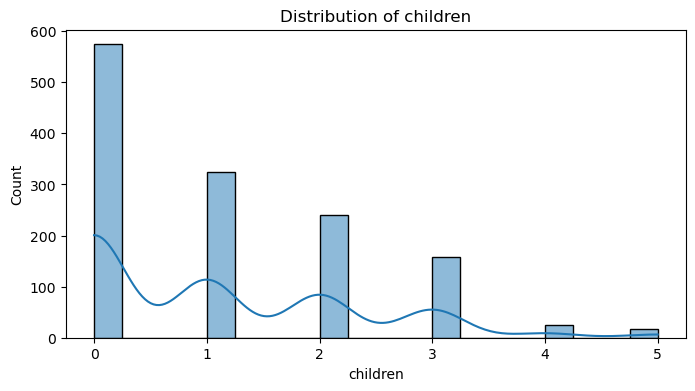

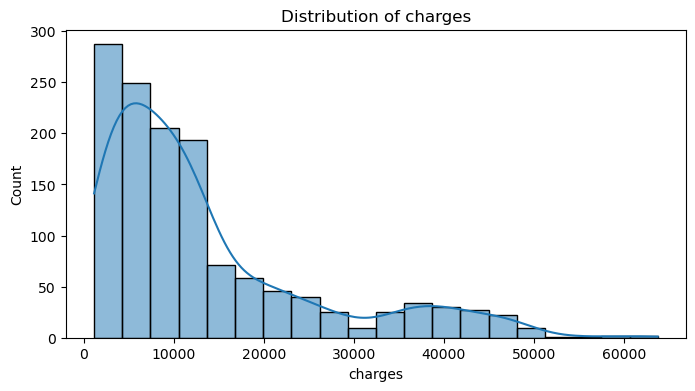

In [12]:
numeric_columns = ['age','bmi','children','charges']
for col in numeric_columns:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], kde=True, bins = 20 )
    plt.title(f'Distribution of {col}')
    plt.show()

<Axes: xlabel='children', ylabel='count'>

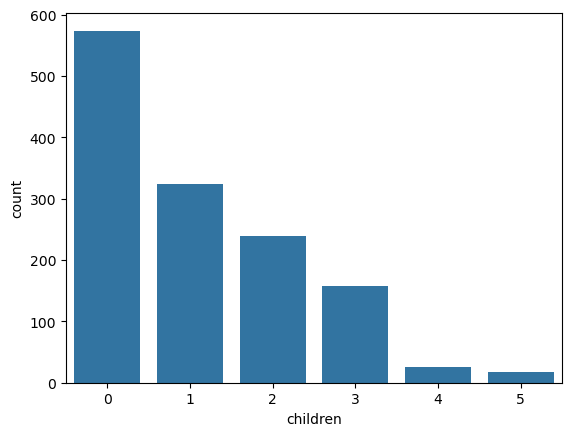

In [14]:
sns.countplot(x = df['children'])

<Axes: xlabel='sex', ylabel='count'>

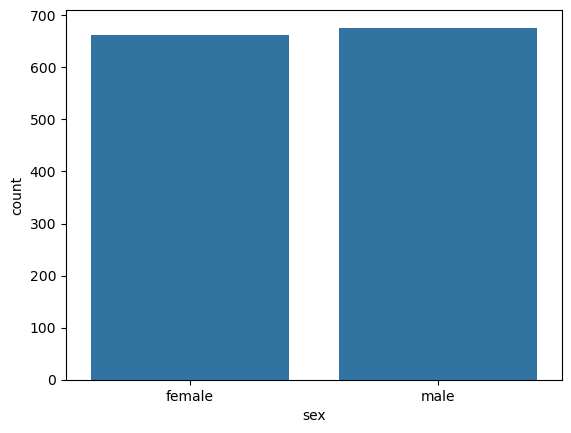

In [15]:

sns.countplot(x =df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

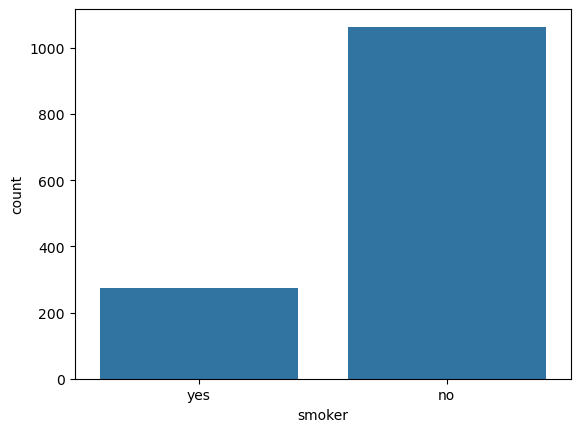

In [16]:
sns.countplot(x = df['smoker'])

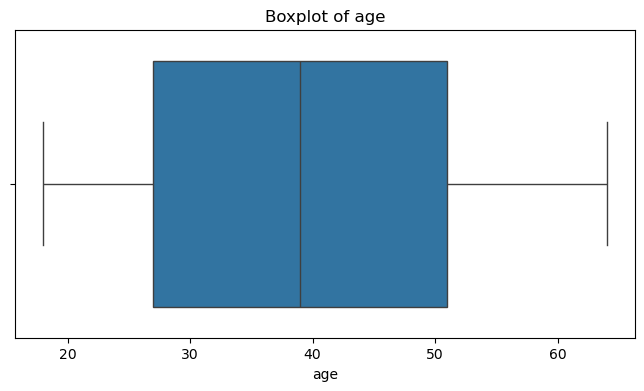

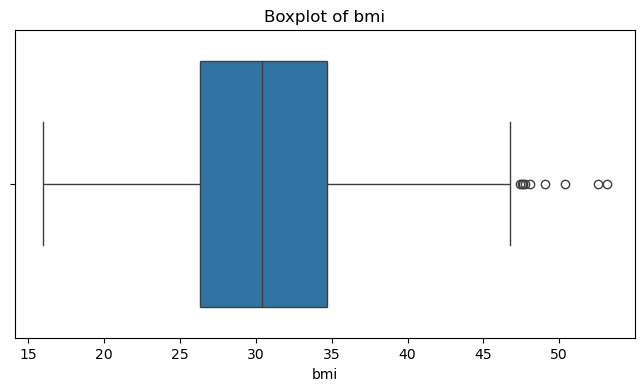

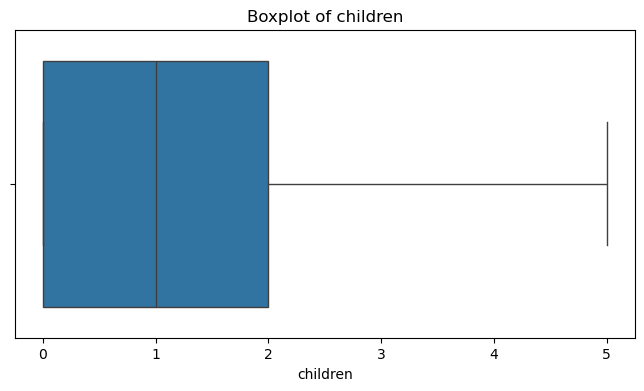

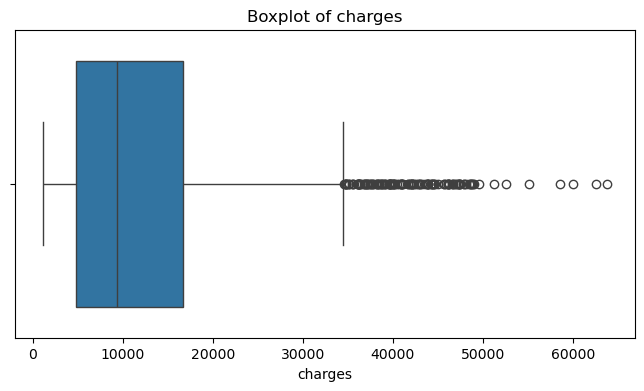

In [17]:
for col in numeric_columns:
    plt.figure(figsize=(8,4))
    sns.boxplot(x = df[col])
    plt.title(f'Boxplot of {col}')

<Axes: >

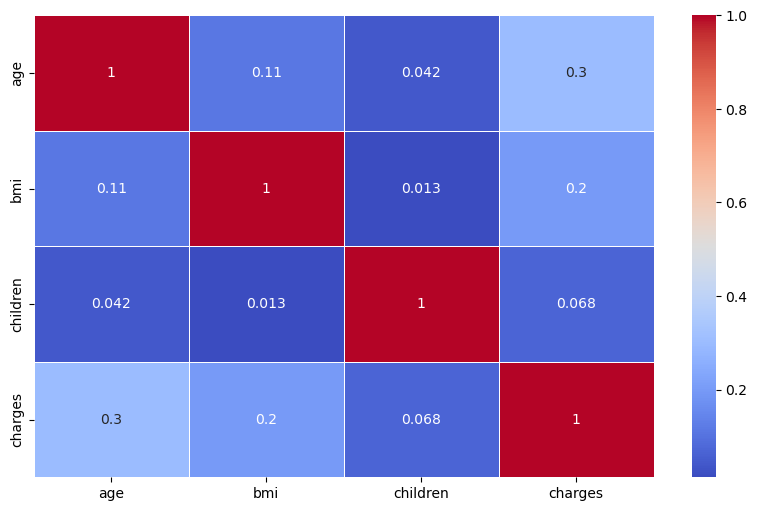

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', linewidths=0.5)

DATA CLEANING AND PRE-PROCESSING


In [65]:
df_cleaned = df.copy()
df_cleaned

,age,is_female,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [66]:
df_cleaned.duplicated().sum()

np.int64(0)

In [67]:
df_cleaned.drop_duplicates(inplace=True)

In [68]:
df_cleaned.shape

(1337, 7)

In [69]:
df_cleaned['is_female'].value_counts()

is_female
male      675
female    662
Name: count, dtype: int64

In [ ]:
df_cleaned['smoker'] = df_cleaned['smoker'].map({'no': 0, 'yes': 1})
df_cleaned['is_female']= df_cleaned['is_female'].map({'male': 0, 'female': 1})

In [71]:

df_cleaned.rename(columns = {'smoker': 'is_smoker'}, inplace=True)

In [72]:
df_cleaned.head()

,age,is_female,bmi,children,is_smoker,region,charges
0,19,1,27.900,0,yes,southwest,16884.92400
1,18,0,33.770,1,no,southeast,1725.55230
2,28,0,33.000,3,no,southeast,4449.46200
3,33,0,22.705,0,no,northwest,21984.47061
4,32,0,28.880,0,no,northwest,3866.85520


In [73]:
df_cleaned['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [74]:
df_cleaned = pd.get_dummies(df_cleaned, columns = ['region'], drop_first=True)

In [75]:
df_cleaned

,age,is_female,bmi,children,is_smoker,charges,region_northwest,region_southeast,region_southwest
0,19,1,27.900,0,yes,16884.92400,False,False,True
1,18,0,33.770,1,no,1725.55230,False,True,False
2,28,0,33.000,3,no,4449.46200,False,True,False
3,33,0,22.705,0,no,21984.47061,True,False,False
4,32,0,28.880,0,no,3866.85520,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,no,10600.54830,True,False,False
1334,18,1,31.920,0,no,2205.98080,False,False,False
1335,18,1,36.850,0,no,1629.83350,False,True,False
1336,21,1,25.800,0,no,2007.94500,False,False,True


In [77]:
df_cleaned['is_smoker'] = df_cleaned['is_smoker'].map({'no': 0, 'yes': 1})
df_cleaned = df_cleaned.astype('int')

df.dtypes

In [ ]:
df_cleaned.dtypes

age                 int64
is_female           int64
bmi                 int64
children            int64
is_smoker           int64
charges             int64
region_northwest    int64
region_southeast    int64
region_southwest    int64
dtype: object

FEATURE ENGINEERING AND EXTRACTION